In [2]:
import os
os.chdir(r"C:\Users\lalit\Documents\nyc-congestion-toll-impact")
print(os.getcwd())

C:\Users\lalit\Documents\nyc-congestion-toll-impact


In [4]:
import os
import duckdb
import pandas as pd

os.chdir(r"C:\Users\lalit\Documents\nyc-congestion-toll-impact")
pd.set_option("display.width", 200)

yoy = duckdb.sql("""
    WITH base AS (
        SELECT CASE WHEN trip_date < DATE '2025-01-01' THEN 'before' ELSE 'after' END AS period,
               company, trip_group,
               SUM(trips) AS trips,
               SUM(sum_rider_cost) / SUM(trips) AS avg_cost,
               SUM(sum_miles) / (SUM(sum_trip_seconds) / 3600) AS mph,
               SUM(sum_driver_pay) / (SUM(sum_trip_seconds) / 3600) AS driver_pay_hr,
               SUM(sum_wait_seconds) / SUM(wait_trips) / 60 AS wait_min
        FROM 'data/summary/*.parquet'
        WHERE (trip_date BETWEEN '2024-02-01' AND '2024-07-31')
           OR (trip_date BETWEEN '2025-02-01' AND '2025-07-31')
        GROUP BY ALL
    )
    SELECT a.company, a.trip_group,
           ROUND(100 * (a.trips / b.trips - 1), 1)                 AS trips_pct,
           ROUND(100 * (a.avg_cost / b.avg_cost - 1), 1)           AS cost_pct,
           ROUND(100 * (a.mph / b.mph - 1), 1)                     AS speed_pct,
           ROUND(100 * (a.driver_pay_hr / b.driver_pay_hr - 1), 1) AS pay_hr_pct,
           ROUND(a.wait_min - b.wait_min, 2)                       AS wait_change_min
    FROM base a JOIN base b USING (company, trip_group)
    WHERE a.period = 'after' AND b.period = 'before'
      AND a.company IN ('Uber', 'Lyft', 'Yellow')
    ORDER BY a.company, a.trip_group
""").df()

yoy

,company,trip_group,trips_pct,cost_pct,speed_pct,pay_hr_pct,wait_change_min
0,Lyft,boundary,12.4,1.7,-0.9,3.7,0.07
1,Lyft,entering,12.5,0.8,-0.0,4.2,0.08
2,Lyft,exiting,3.6,1.3,0.4,4.2,0.13
3,Lyft,inside,10.3,7.0,3.6,4.5,0.02
4,Lyft,outside,10.0,-3.4,-2.6,2.4,0.13
5,Uber,boundary,-10.9,11.8,2.8,7.0,0.06
6,Uber,entering,-11.1,13.1,3.4,8.0,0.39
7,Uber,exiting,-7.2,12.4,3.2,8.2,0.14
8,Uber,inside,-13.4,18.5,1.0,8.3,-0.10
9,Uber,outside,0.2,2.2,-0.8,3.0,0.37


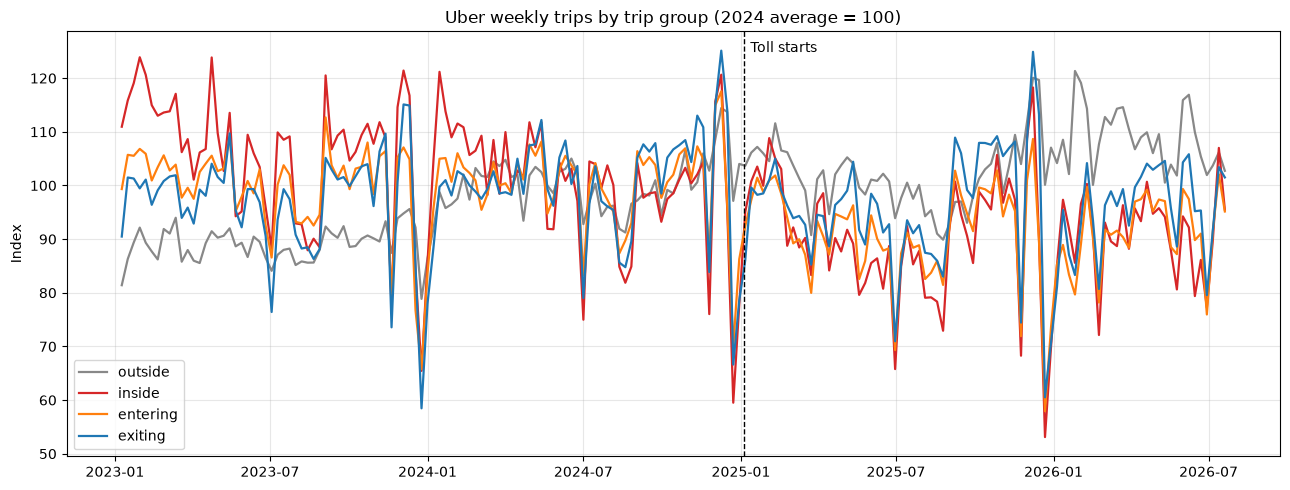

In [5]:
import matplotlib.pyplot as plt

weekly = duckdb.sql("""
    SELECT date_trunc('week', trip_date) AS week, trip_group, SUM(trips) AS trips
    FROM 'data/summary/*.parquet'
    WHERE company = 'Uber'
      AND trip_group IN ('inside', 'entering', 'exiting', 'outside')
      AND trip_date >= '2023-01-09' AND trip_date < '2026-07-27'
    GROUP BY ALL
""").df()

pivot = weekly.pivot(index="week", columns="trip_group", values="trips").sort_index()

# index each group to its 2024 average = 100, so all groups share one scale
base = pivot.loc["2024-01-01":"2024-12-31"].mean()
indexed = pivot / base * 100

fig, ax = plt.subplots(figsize=(13, 5))
for group, color in [("outside", "#888888"), ("inside", "#d62728"),
                     ("entering", "#ff7f0e"), ("exiting", "#1f77b4")]:
    ax.plot(indexed.index, indexed[group], label=group, color=color, lw=1.6)

ax.axvline(pd.Timestamp("2025-01-05"), color="black", ls="--", lw=1)
ax.text(pd.Timestamp("2025-01-12"), ax.get_ylim()[1] * 0.97, "Toll starts", fontsize=10)
ax.set_title("Uber weekly trips by trip group (2024 average = 100)")
ax.set_ylabel("Index")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/parallel_trends_uber.png", dpi=150)
plt.show()

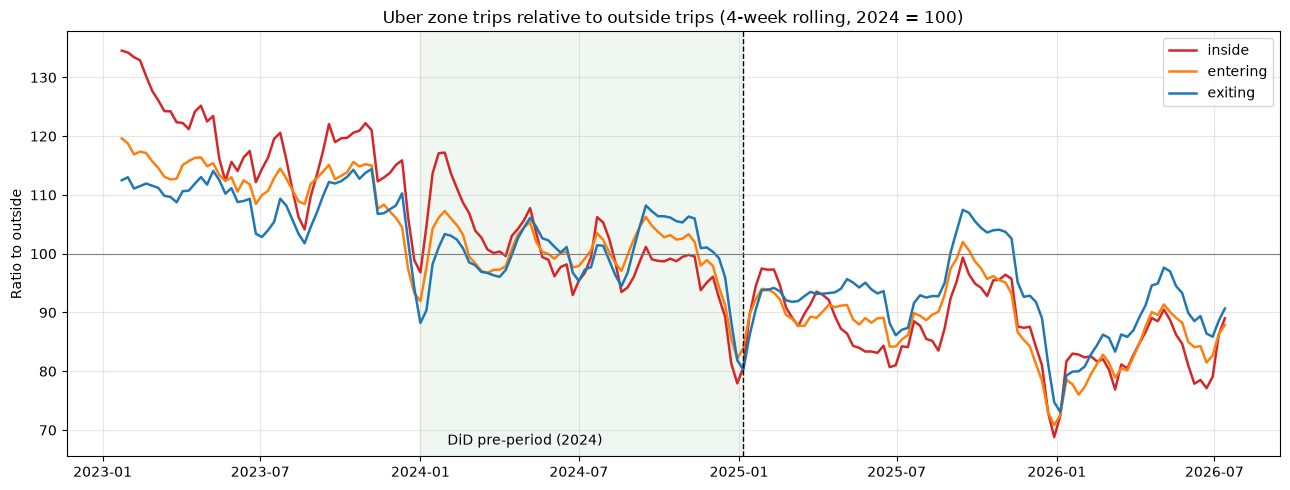

In [6]:
ratio = indexed[["inside", "entering", "exiting"]].div(indexed["outside"], axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
for group, color in [("inside", "#d62728"), ("entering", "#ff7f0e"), ("exiting", "#1f77b4")]:
    ax.plot(ratio.index, ratio[group].rolling(4, center=True).mean(),
            label=group, color=color, lw=1.8)

ax.axvline(pd.Timestamp("2025-01-05"), color="black", ls="--", lw=1)
ax.axhline(100, color="grey", lw=0.8)
ax.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-01-05"), color="green", alpha=0.06)
ax.text(pd.Timestamp("2024-02-01"), ax.get_ylim()[0] + 2, "DiD pre-period (2024)", fontsize=10)
ax.set_title("Uber zone trips relative to outside trips (4-week rolling, 2024 = 100)")
ax.set_ylabel("Ratio to outside")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/ratio_to_outside_uber.png", dpi=150)
plt.show()

In [8]:
import numpy as np
import statsmodels.formula.api as smf

d = duckdb.sql("""
    SELECT trip_date, trip_group, SUM(trips) AS trips
    FROM 'data/summary/*.parquet'
    WHERE company = 'Uber'
      AND trip_group IN ('inside', 'entering', 'exiting', 'outside')
      AND trip_date BETWEEN '2024-01-01' AND '2025-12-31'
    GROUP BY ALL
""").df()

d["trip_date"] = pd.to_datetime(d["trip_date"])
d["post"] = (d["trip_date"] >= "2025-01-05").astype(int)
d["log_trips"] = np.log(d["trips"])
d["dow"] = d["trip_date"].dt.dayofweek
d["week"] = d["trip_date"].dt.to_period("W").astype(str)
for g in ["inside", "entering", "exiting"]:
    d[f"{g}_post"] = ((d["trip_group"] == g) & (d["post"] == 1)).astype(int)

# weekday pattern of each zone group relative to outside (outside's is absorbed by the date effects)
d["group_dow"] = np.where(d["trip_group"] == "outside", "outside",
                          d["trip_group"] + "_" + d["dow"].astype(str))

model = smf.ols(
    "log_trips ~ inside_post + entering_post + exiting_post + C(group_dow) + C(trip_date)",
    data=d,
).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(d["week"])[0]})

res = pd.DataFrame({"coef": model.params, "se": model.bse, "p_value": model.pvalues}) \
        .loc[["inside_post", "entering_post", "exiting_post"]]
res["effect_pct"] = (np.exp(res["coef"]) - 1) * 100
res["ci_low_pct"] = (np.exp(res["coef"] - 1.96 * res["se"]) - 1) * 100
res["ci_high_pct"] = (np.exp(res["coef"] + 1.96 * res["se"]) - 1) * 100
res.round(3)

,coef,se,p_value,effect_pct,ci_low_pct,ci_high_pct
inside_post,-0.119,0.027,0.000,-11.257,-15.805,-6.463
entering_post,-0.108,0.020,0.000,-10.200,-13.622,-6.642
exiting_post,-0.060,0.022,0.007,-5.837,-9.836,-1.660


In [9]:
res.round(3).to_csv("outputs/did_uber_trips.csv")

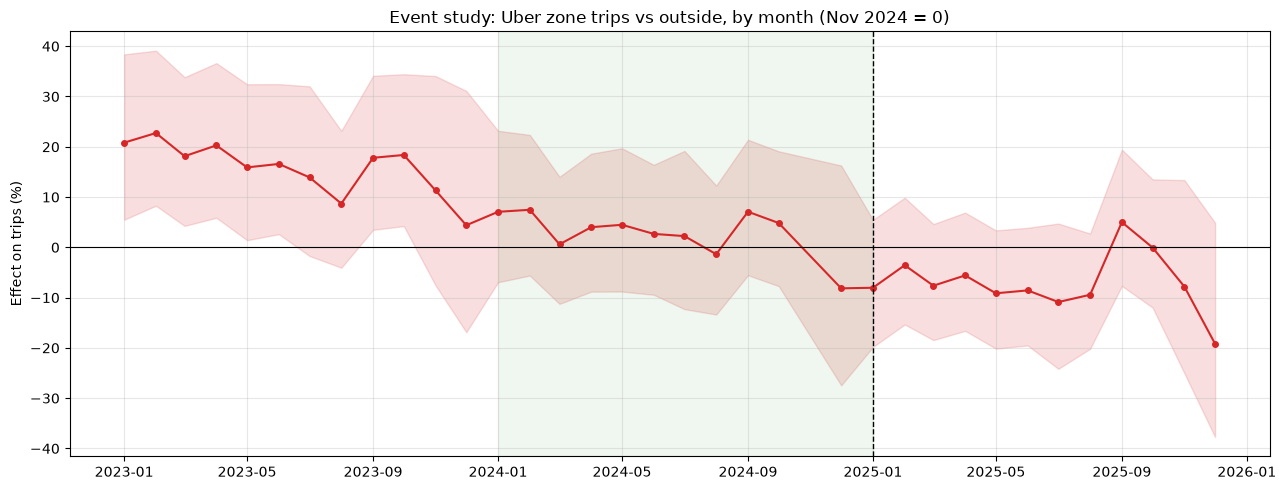

In [10]:
d = duckdb.sql("""
    SELECT trip_date, trip_group, SUM(trips) AS trips
    FROM 'data/summary/*.parquet'
    WHERE company = 'Uber'
      AND trip_group IN ('inside', 'entering', 'exiting', 'outside')
      AND trip_date BETWEEN '2023-01-01' AND '2025-12-31'
    GROUP BY ALL
""").df()

d["trip_date"] = pd.to_datetime(d["trip_date"])
d["log_trips"] = np.log(d["trips"])
d["dow"] = d["trip_date"].dt.dayofweek
d["week"] = d["trip_date"].dt.to_period("W").astype(str)
d["month"] = d["trip_date"].dt.strftime("%Y_%m")
d["group_dow"] = np.where(d["trip_group"] == "outside", "outside",
                          d["trip_group"] + "_" + d["dow"].astype(str))

# zone trips (inside + entering + exiting) vs outside, one effect per month
zone = (d["trip_group"] != "outside").astype(int)
REF = "2024_11"                      # reference month: Nov 2024 (last normal pre-toll month)
months = sorted(m for m in d["month"].unique() if m != REF)
for m in months:
    d[f"z_{m}"] = zone * (d["month"] == m).astype(int)

formula = "log_trips ~ " + " + ".join(f"z_{m}" for m in months) + " + C(group_dow) + C(trip_date)"
es = smf.ols(formula, data=d).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(d["week"])[0]})

coefs = pd.DataFrame({
    "month": pd.to_datetime([m.replace("_", "-") + "-01" for m in months]),
    "effect_pct": [(np.exp(es.params[f"z_{m}"]) - 1) * 100 for m in months],
    "low": [(np.exp(es.params[f"z_{m}"] - 1.96 * es.bse[f"z_{m}"]) - 1) * 100 for m in months],
    "high": [(np.exp(es.params[f"z_{m}"] + 1.96 * es.bse[f"z_{m}"]) - 1) * 100 for m in months],
})

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(coefs["month"], coefs["low"], coefs["high"], color="#d62728", alpha=0.15)
ax.plot(coefs["month"], coefs["effect_pct"], "o-", color="#d62728", ms=4)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(pd.Timestamp("2025-01-01"), color="black", ls="--", lw=1)
ax.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31"), color="green", alpha=0.06)
ax.set_title("Event study: Uber zone trips vs outside, by month (Nov 2024 = 0)")
ax.set_ylabel("Effect on trips (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/event_study_uber.png", dpi=150)
plt.show()

coefs.to_csv("outputs/event_study_uber.csv", index=False)

In [11]:
d2 = d[(d["trip_date"] >= "2024-01-01") & (d["trip_date"] <= "2025-12-31")].copy()
d2["post"] = (d2["trip_date"] >= "2025-01-05").astype(int)
d2["t"] = (d2["trip_date"] - pd.Timestamp("2024-01-01")).dt.days / 365   # years since start

for g in ["inside", "entering", "exiting"]:
    d2[f"{g}_post"] = ((d2["trip_group"] == g) & (d2["post"] == 1)).astype(int)
    d2[f"{g}_trend"] = (d2["trip_group"] == g).astype(int) * d2["t"]      # each group's own linear trend

results = {}
for name, extra in [("plain DiD", ""), ("with group trends", " + inside_trend + entering_trend + exiting_trend")]:
    m = smf.ols("log_trips ~ inside_post + entering_post + exiting_post" + extra +
                " + C(group_dow) + C(trip_date)", data=d2) \
           .fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(d2["week"])[0]})
    for g in ["inside", "entering", "exiting"]:
        b, se = m.params[f"{g}_post"], m.bse[f"{g}_post"]
        results[(name, g)] = {"effect_pct": (np.exp(b) - 1) * 100,
                              "ci_low": (np.exp(b - 1.96 * se) - 1) * 100,
                              "ci_high": (np.exp(b + 1.96 * se) - 1) * 100,
                              "p_value": m.pvalues[f"{g}_post"]}

robust = pd.DataFrame(results).T.round(2)
robust.to_csv("outputs/did_robustness_uber.csv")
robust

effect_pct  ci_low  ci_high  p_value
plain DiD         inside        -11.26  -15.80    -6.46     0.00
                  entering      -10.20  -13.62    -6.64     0.00
                  exiting        -5.84   -9.84    -1.66     0.01
with group trends inside          4.31   -6.73    16.66     0.46
                  entering       -3.23  -10.98     5.19     0.44
                  exiting        -5.89  -15.24     4.49     0.26

22 uptown Manhattan control zones: [24, 41, 42, 74, 75, 116, 120, 127, 128, 151, 152, 153, 166, 194, 202, 236, 238, 239, 243, 244, 262, 263]


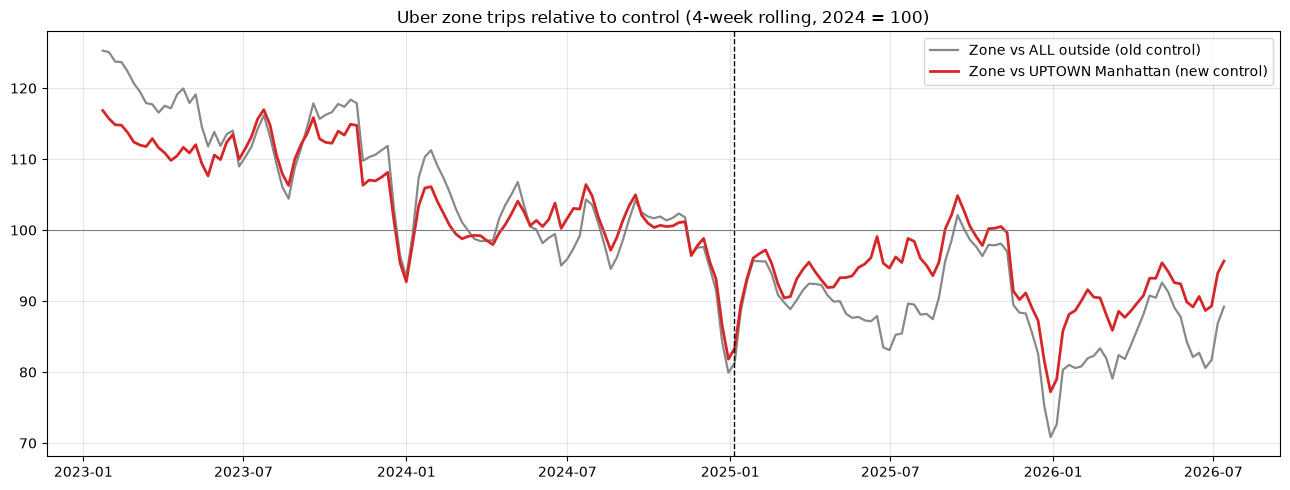

In [13]:
import os, sys, requests
sys.path.append("src")
from zones import CBD_ZONES, BOUNDARY_ZONES

# download the zone lookup once (browser header needed) and keep a local copy
LOOKUP = "data/taxi_zone_lookup.csv"
if not os.path.exists(LOOKUP):
    r = requests.get("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
                     headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}, timeout=60)
    r.raise_for_status()
    open(LOOKUP, "wb").write(r.content)
lookup = pd.read_csv(LOOKUP)

uptown = lookup[(lookup["Borough"] == "Manhattan")
                & (~lookup["LocationID"].isin(CBD_ZONES + BOUNDARY_ZONES))
                & (~lookup["LocationID"].isin([103, 104, 105]))]      # harbor islands
print(len(uptown), "uptown Manhattan control zones:", sorted(uptown["LocationID"]))
uptown_ids = ",".join(map(str, uptown["LocationID"]))

w = duckdb.sql(f"""
    SELECT date_trunc('week', trip_date) AS week,
           SUM(trips) FILTER (WHERE trip_group IN ('inside','entering','exiting')) AS zone,
           SUM(trips) FILTER (WHERE trip_group = 'outside') AS all_outside,
           SUM(trips) FILTER (WHERE trip_group = 'outside' AND pu_zone IN ({uptown_ids})) AS uptown
    FROM 'data/summary/*.parquet'
    WHERE company = 'Uber' AND trip_date >= '2023-01-09' AND trip_date < '2026-07-27'
    GROUP BY 1 ORDER BY 1
""").df().set_index("week")

ratios = pd.DataFrame({
    "vs all outside": w["zone"] / w["all_outside"],
    "vs uptown Manhattan": w["zone"] / w["uptown"],
})
ratios = ratios / ratios.loc["2024-01-01":"2024-12-31"].mean() * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ratios.index, ratios["vs all outside"].rolling(4, center=True).mean(),
        color="#888888", lw=1.6, label="Zone vs ALL outside (old control)")
ax.plot(ratios.index, ratios["vs uptown Manhattan"].rolling(4, center=True).mean(),
        color="#d62728", lw=2, label="Zone vs UPTOWN Manhattan (new control)")
ax.axvline(pd.Timestamp("2025-01-05"), color="black", ls="--", lw=1)
ax.axhline(100, color="grey", lw=0.8)
ax.set_title("Uber zone trips relative to control (4-week rolling, 2024 = 100)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/control_comparison_uber.png", dpi=150)
plt.show()

In [15]:
k = duckdb.sql(f"""
    SELECT trip_date,
           CASE WHEN trip_group = 'outside' THEN 'control' ELSE trip_group END AS grp,
           SUM(trips) AS trips,
           SUM(sum_rider_cost) / SUM(trips) AS avg_cost,
           SUM(sum_miles) / (SUM(sum_trip_seconds) / 3600) AS mph,
           SUM(sum_driver_pay) / (SUM(sum_trip_seconds) / 3600) AS pay_hr
    FROM 'data/summary/*.parquet'
    WHERE company = 'Uber'
      AND trip_date BETWEEN '2024-01-01' AND '2025-12-31'
      AND (trip_group IN ('inside', 'entering', 'exiting')
           OR (trip_group = 'outside' AND pu_zone IN ({uptown_ids})))
    GROUP BY ALL
""").df()

k["trip_date"] = pd.to_datetime(k["trip_date"])
k["post"] = (k["trip_date"] >= "2025-01-05").astype(int)
k["t"] = (k["trip_date"] - pd.Timestamp("2024-01-01")).dt.days / 365
k["week"] = k["trip_date"].dt.to_period("W").astype(str)
k["dow"] = k["trip_date"].dt.dayofweek
k["group_dow"] = np.where(k["grp"] == "control", "control", k["grp"] + "_" + k["dow"].astype(str))
for g in ["inside", "entering", "exiting"]:
    k[f"{g}_post"] = ((k["grp"] == g) & (k["post"] == 1)).astype(int)
    k[f"{g}_trend"] = (k["grp"] == g).astype(int) * k["t"]

rows = []
for outcome in ["trips", "avg_cost", "mph", "pay_hr"]:
    k["y"] = np.log(k[outcome])
    for spec, extra in [("plain", ""), ("with trends", " + inside_trend + entering_trend + exiting_trend")]:
        m = smf.ols("y ~ inside_post + entering_post + exiting_post" + extra +
                    " + C(group_dow) + C(trip_date)", data=k) \
               .fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(k["week"])[0]})
        for g in ["inside", "entering", "exiting"]:
            b, se = m.params[f"{g}_post"], m.bse[f"{g}_post"]
            rows.append({"outcome": outcome, "spec": spec, "group": g,
                         "effect_pct": (np.exp(b) - 1) * 100,
                         "ci_low": (np.exp(b - 1.96 * se) - 1) * 100,
                         "ci_high": (np.exp(b + 1.96 * se) - 1) * 100,
                         "p_value": m.pvalues[f"{g}_post"]})

kpi = pd.DataFrame(rows).round(2)
kpi.to_csv("outputs/did_kpis_uptown_control_uber.csv", index=False)
kpi.pivot_table(index=["outcome", "group"], columns="spec", values=["effect_pct", "p_value"])

effect_pct             p_value            
spec                   plain with trends   plain with trends
outcome  group                                              
avg_cost entering       9.27        4.97    0.00        0.01
         exiting        7.38        1.73    0.00        0.28
         inside        13.89        0.08    0.00        0.97
mph      entering       3.68       13.76    0.00        0.00
         exiting        3.30        8.18    0.00        0.00
         inside         1.48       12.91    0.14        0.00
pay_hr   entering       4.14        6.48    0.00        0.00
         exiting        3.62        2.95    0.00        0.00
         inside         3.38       -2.87    0.00        0.12
trips    entering      -6.03       -2.97    0.00        0.44
         exiting       -1.46       -5.64    0.47        0.24
         inside        -7.13        4.59    0.00        0.39